# 17장 - 데이터 품질 진단 프레임워크 실습
## 결측치 처리 및 이상치 처리 워크플로우

이 노트북은 **데이터 품질 진단 프레임워크** 관점에서 결측치와 이상치 처리를 실습합니다.

실습 데이터는 의사결정 흐름이 잘 드러나도록 직접 생성합니다.

| 파트 | 데이터셋 | 핵심 내용 |
|---|---|---|
| Part A | 고객 활동 데이터 | 결측 발견 → 원인 확인 → drop/fill/flag/separate/hold 선택 → 처리 전후 검증 |
| Part B | 주문 거래 데이터 | IQR, z-score, 히스토그램, 박스플롯 탐지 → 오류/이상치 구분 → 제거/클리핑/대체/로그변환/태깅 |

## 핵심 원칙

결측치와 이상치는 기계적으로 처리하지 않습니다.

- 결측이 무작위인가, 특정 집단에 몰려 있는가?
- 결측 자체가 의미 있는 신호인가?
- 결측을 메울 근거가 도메인에 있는가?
- 이상치는 실제 가능한 값인가, 도메인상 불가능한 오류인가?
- 제거하면 중요한 신호를 잃는가?

# 0. 환경 준비

Pandas, NumPy, Matplotlib을 사용합니다.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import platform

path = "c:/fonts/malgun.ttf"
from matplotlib import font_manager, rc
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~') 

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.unicode_minus'] = False

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print('numpy:', np.__version__)
print('pandas:', pd.__version__)

# ------------------------------------------------------------
# 결과 해석:
# - 이 셀은 실습 환경을 준비하는 단계입니다.
# - 라이브러리와 화면 출력 옵션이 정상적으로 설정되면 이후 결측치/이상치 진단 코드를 실행할 준비가 된 것입니다.
# - 한글 폰트 설정은 실행 환경에 따라 다르게 동작할 수 있으므로, 그래프 한글이 깨지면 폰트 경로를 환경에 맞게 조정합니다.
# ------------------------------------------------------------

numpy: 2.3.5
pandas: 2.3.3


# Part A. 결측치 처리 워크플로우

## A-1. 결측치 실습 데이터 생성

온라인 서비스의 고객 활동 데이터를 분석하여 고객 이탈 가능성을 진단하는 상황입니다.

| 컬럼 | 의미 | 결측 발생 시나리오 |
|---|---|---|
| `segment` | 고객군 | 없음 |
| `signup_channel` | 가입 채널 | 일부 수집 누락 |
| `age` | 나이 | 고객 미입력 |
| `monthly_spend` | 월 평균 구매액 | 없음 |
| `recent_login_days` | 최근 로그인 후 경과일 | 배치 지연 또는 이탈 고객에서 누락 |
| `refund_rate` | 환불률 | 수집 실패 또는 정의 불명확 |
| `cs_count` | 고객센터 문의 수 | 문의 경험 없는 비해당 고객 가능 |
| `churned` | 이탈 여부 | 없음 |

In [2]:
# ------------------------------------------------------------
# 결측치 실습용 고객 활동 데이터 생성
# ------------------------------------------------------------
# 의도적으로 여러 유형의 결측을 넣습니다.
# - age: 고객 미입력
# - recent_login_days: 이탈 고객에게 몰린 결측 가능성
# - refund_rate: 0과 결측을 구분해야 하는 수집 실패
# - cs_count: 문의 경험이 없는 비해당 집단 가능성
# ------------------------------------------------------------

n = 350
customer = pd.DataFrame({
    'customer_id': np.arange(10001, 10001 + n),
    'segment': rng.choice(['Basic', 'Silver', 'Gold', 'VIP'], size=n, p=[0.45, 0.30, 0.20, 0.05]),
    'signup_channel': rng.choice(['Web', 'App', 'Partner', 'Offline'], size=n, p=[0.45, 0.35, 0.15, 0.05]),
    'age': np.round(rng.normal(39, 11, size=n)).astype(int),
    'monthly_spend': np.round(rng.gamma(shape=2.2, scale=45000, size=n), -2),
    'recent_login_days': rng.integers(0, 120, size=n),
    'refund_rate': np.round(rng.beta(1.2, 18, size=n), 3),
    'cs_count': rng.poisson(1.3, size=n),
    'churned': rng.choice([0, 1], size=n, p=[0.78, 0.22])
})

customer['age'] = customer['age'].clip(18, 75)
customer.loc[customer['segment'] == 'VIP', 'monthly_spend'] *= 2.5
customer['monthly_spend'] = customer['monthly_spend'].round(-2)

# 결측 주입
customer.loc[rng.choice(customer.index, size=22, replace=False), 'age'] = np.nan
churned_idx = customer.index[customer['churned'] == 1].to_numpy()
customer.loc[rng.choice(churned_idx, size=min(35, len(churned_idx)), replace=False), 'recent_login_days'] = np.nan
customer.loc[rng.choice(customer.index, size=38, replace=False), 'refund_rate'] = np.nan
customer.loc[rng.choice(customer.index, size=45, replace=False), 'cs_count'] = np.nan
customer.loc[rng.choice(customer.index, size=8, replace=False), 'signup_channel'] = np.nan

customer.head()

# ------------------------------------------------------------
# 결과 해석:
# - 고객 활동 데이터가 정상적으로 생성되면 각 행은 한 명의 고객을 의미합니다.
# - age, recent_login_days, refund_rate, cs_count, signup_channel에는 의도적으로 서로 다른 원인의 결측이 포함되어 있습니다.
# - 이 데이터는 단순 fillna 실습이 아니라 결측의 의미를 구분하기 위한 교육용 데이터입니다.
# ------------------------------------------------------------

,customer_id,segment,signup_channel,age,monthly_spend,recent_login_days,refund_rate,cs_count,churned
0,10001,Gold,App,25.0,127900.0,84.0,0.033,3.0,0
1,10002,Basic,Web,48.0,63500.0,41.0,0.060,1.0,0
2,10003,Gold,App,43.0,86200.0,20.0,0.024,1.0,0
3,10004,Silver,App,65.0,166100.0,56.0,0.018,1.0,0
4,10005,Basic,App,44.0,97100.0,NaN,0.051,1.0,1


## A-2. 1단계: 결측 발견

먼저 어느 컬럼에 결측이 얼마나 있는지 확인합니다. 결측 진단의 첫 단계는 **결측 개수와 결측률**을 계산하는 것입니다.

In [3]:
missing_report = pd.DataFrame({
    'missing_count': customer.isna().sum(),
    'missing_rate': customer.isna().mean()
}).sort_values('missing_rate', ascending=False)
missing_report

# ------------------------------------------------------------
# 결과 해석:
# - missing_count는 컬럼별 결측 개수이고, missing_rate는 전체 행 대비 결측 비율입니다.
# - 결측률이 높은 컬럼부터 우선 점검하되, 결측률이 낮아도 업무적으로 중요한 컬럼이면 반드시 원인을 확인해야 합니다.
# - 이 결과는 이후 결측 처리 전략을 정하는 기준 자료로 사용됩니다.
# ------------------------------------------------------------

,missing_count,missing_rate
cs_count,45,0.128571
refund_rate,38,0.108571
recent_login_days,35,0.100000
age,22,0.062857
signup_channel,8,0.022857
customer_id,0,0.000000
segment,0,0.000000
monthly_spend,0,0.000000
churned,0,0.000000


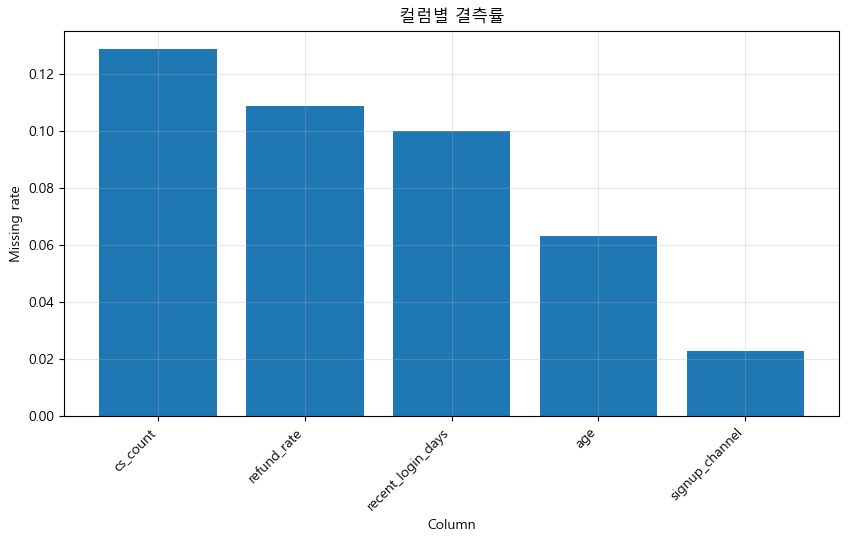

In [4]:
# 컬럼별 결측률 시각화
missing_report_nonzero = missing_report[missing_report['missing_count'] > 0]
plt.figure(figsize=(10, 5))
plt.bar(missing_report_nonzero.index, missing_report_nonzero['missing_rate'])
plt.title('컬럼별 결측률')
plt.xlabel('Column')
plt.ylabel('Missing rate')
plt.xticks(rotation=45, ha='right')
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 막대가 높을수록 해당 컬럼의 결측 비율이 높다는 뜻입니다.
# - 시각화 결과를 통해 결측 문제가 집중된 컬럼을 빠르게 식별할 수 있습니다.
# - 결측률이 0인 컬럼은 그래프에서 제외되어 주요 결측 컬럼만 확인됩니다.
# ------------------------------------------------------------

## A-3. 2단계: 결측 원인 확인

단순히 결측률만 보는 것은 부족합니다. 결측이 특정 그룹에 몰려 있으면 결측 자체가 중요한 신호일 수 있습니다.

확인 항목:

1. 고객군별 결측률
2. 이탈 여부별 결측률
3. 결측 패턴 매트릭스

In [5]:
# 고객군별 결측률
missing_by_segment = customer.groupby('segment').apply(lambda g: g.isna().mean())
missing_by_segment[['age', 'recent_login_days', 'refund_rate', 'cs_count', 'signup_channel']]

# ------------------------------------------------------------
# 결과 해석:
# - segment별 결측률이 다르면 결측이 무작위가 아니라 특정 고객군에 편향되어 있을 가능성이 있습니다.
# - 특정 segment에서만 결측률이 높다면 수집 경로나 업무 프로세스 차이를 의심해야 합니다.
# - 이 경우 전체 중앙값 대체보다 segment별 중앙값 대체가 더 합리적일 수 있습니다.
# ------------------------------------------------------------

C:\Users\yhkim\AppData\Local\Temp\ipykernel_15816\621325926.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_segment = customer.groupby('segment').apply(lambda g: g.isna().mean())


,age,recent_login_days,refund_rate,cs_count,signup_channel
segment,,,,,
Basic,0.069182,0.113208,0.119497,0.132075,0.006289
Gold,0.040000,0.106667,0.066667,0.093333,0.026667
Silver,0.067961,0.067961,0.106796,0.155340,0.038835
VIP,0.076923,0.153846,0.230769,0.076923,0.076923


In [6]:
# 이탈 여부별 결측률
missing_by_churn = customer.groupby('churned').apply(lambda g: g.isna().mean())
missing_by_churn[['recent_login_days', 'refund_rate', 'cs_count', 'age']]

# ------------------------------------------------------------
# 결과 해석:
# - churned 값별 결측률 차이는 결측 자체가 이탈과 관련된 신호인지 판단하는 데 사용됩니다.
# - 예를 들어 이탈 고객에서 recent_login_days 결측이 높다면 단순 대체만 하면 중요한 신호를 잃을 수 있습니다.
# - 이런 컬럼은 값 대체와 함께 missing flag를 별도로 생성하는 것이 바람직합니다.
# ------------------------------------------------------------

C:\Users\yhkim\AppData\Local\Temp\ipykernel_15816\3546007950.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_churn = customer.groupby('churned').apply(lambda g: g.isna().mean())


,recent_login_days,refund_rate,cs_count,age
churned,,,,
0,0.000000,0.119134,0.133574,0.054152
1,0.479452,0.068493,0.109589,0.095890


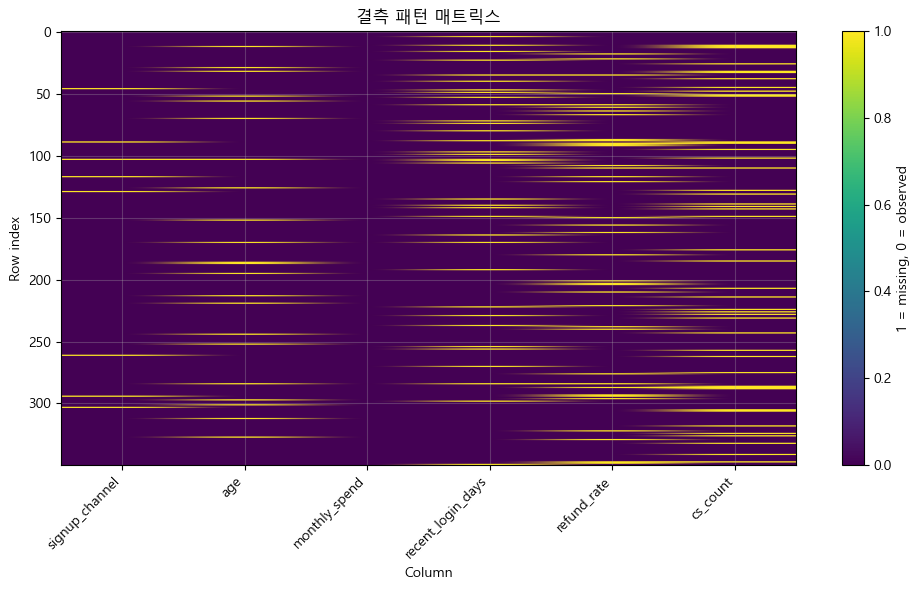

In [7]:
# 결측 패턴 매트릭스
cols_to_check = ['signup_channel', 'age', 'monthly_spend', 'recent_login_days', 'refund_rate', 'cs_count']
missing_matrix = customer[cols_to_check].isna().astype(int)
plt.figure(figsize=(10, 6))
plt.imshow(missing_matrix.values, aspect='auto')
plt.title('결측 패턴 매트릭스')
plt.xlabel('Column')
plt.ylabel('Row index')
plt.xticks(range(len(cols_to_check)), cols_to_check, rotation=45, ha='right')
plt.colorbar(label='1 = missing, 0 = observed')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 결측 패턴 매트릭스에서 진한 부분은 결측이 있는 위치를 의미합니다.
# - 결측이 특정 행 구간이나 특정 컬럼 조합에 몰려 있으면 수집 시스템 또는 업무 규칙 문제일 수 있습니다.
# - 무작위로 흩어진 결측과 구조적으로 반복되는 결측은 처리 전략이 달라야 합니다.
# ------------------------------------------------------------

## A-4. 3단계: 결측 처리 의사결정 테이블

결측 처리는 다음과 같이 나누어 판단합니다.

| 전략 | 의미 | 적용 조건 |
|---|---|---|
| `drop` | 행 또는 컬럼 제거 | 결측 비율이 낮고 정보 손실이 작을 때 |
| `fill` | 값 대체 | 도메인 근거가 있고 값 의미가 유지될 때 |
| `flag` | 결측 여부 변수를 추가 | 결측 자체가 중요한 신호일 때 |
| `separate` | 비해당 집단으로 별도 처리 | 결측이 없음이 아니라 해당 없음일 때 |
| `hold` | 보류 | 원천 데이터 재확인이 필요할 때 |

In [8]:
missing_decision = pd.DataFrame([
    {'column': 'signup_channel', 'reason': '수집 누락', 'decision': 'fill', 'action': 'Unknown으로 대체', 'validation': 'Unknown 비율 확인'},
    {'column': 'age', 'reason': '고객 미입력', 'decision': 'fill', 'action': 'segment별 중앙값 대체', 'validation': '처리 전후 분포 비교'},
    {'column': 'recent_login_days', 'reason': '배치 지연 또는 이탈 고객에서 결측', 'decision': 'fill + flag', 'action': '결측 flag 생성 후 segment별 중앙값 대체', 'validation': 'flag와 churned 관계 확인'},
    {'column': 'refund_rate', 'reason': '수집 실패 또는 정의 불명확', 'decision': 'flag + hold', 'action': '결측 flag 생성 후 임시 중앙값 대체', 'validation': '0 대체와 중앙값 대체 비교'},
    {'column': 'cs_count', 'reason': '문의 경험 없는 비해당 고객 가능', 'decision': 'separate + fill', 'action': '비해당 flag 생성 후 0 대체', 'validation': 'flag별 churned 비율 비교'}
])
missing_decision

# ------------------------------------------------------------
# 결과 해석:
# - 이 표는 결측 처리 의사결정을 문서화한 것입니다.
# - 각 컬럼에 대해 결측 원인, 처리 방법, 검증 기준을 함께 남기는 것이 중요합니다.
# - 실무에서는 이와 같은 테이블을 데이터 품질 리포트나 전처리 명세서로 관리합니다.
# ------------------------------------------------------------

,column,reason,decision,action,validation
0,signup_channel,수집 누락,fill,Unknown으로 대체,Unknown 비율 확인
1,age,고객 미입력,fill,segment별 중앙값 대체,처리 전후 분포 비교
2,recent_login_days,배치 지연 또는 이탈 고객에서 결측,fill + flag,결측 flag 생성 후 segment별 중앙값 대체,flag와 churned 관계 확인
3,refund_rate,수집 실패 또는 정의 불명확,flag + hold,결측 flag 생성 후 임시 중앙값 대체,0 대체와 중앙값 대체 비교
4,cs_count,문의 경험 없는 비해당 고객 가능,separate + fill,비해당 flag 생성 후 0 대체,flag별 churned 비율 비교


## A-5. Bad Case 비교: 0 대체 vs 중앙값 대체

`refund_rate`는 환불률입니다. 결측을 무조건 0으로 채우면 **실제 환불률 0**과 **알 수 없음**이 섞입니다.

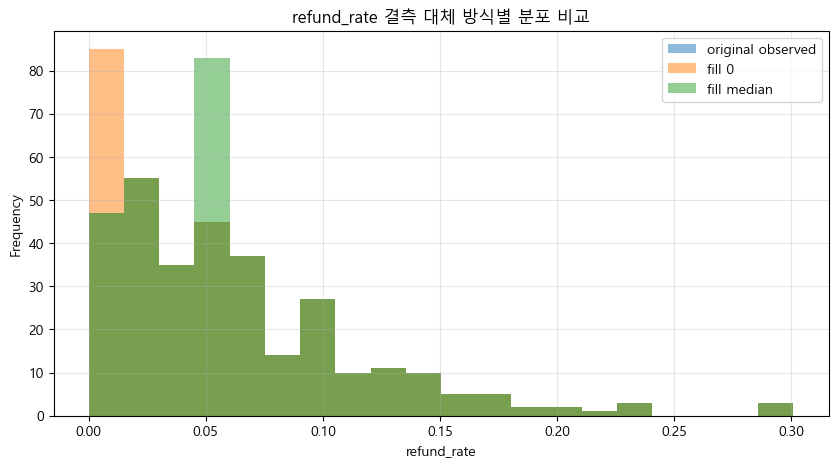

,original_observed,fill_zero,fill_median
count,312.000000,350.000000,350.000000
mean,0.063692,0.056777,0.062423
std,0.053010,0.053831,0.050173
min,0.000000,0.000000,0.000000
25%,0.024000,0.016000,0.025000
50%,0.052000,0.045500,0.052000
75%,0.091250,0.081250,0.081250
max,0.301000,0.301000,0.301000


In [9]:
refund_original = customer['refund_rate']
refund_fill_zero = refund_original.fillna(0)
refund_fill_median = refund_original.fillna(refund_original.median())

plt.figure(figsize=(10, 5))
plt.hist(refund_original.dropna(), bins=20, alpha=0.5, label='original observed')
plt.hist(refund_fill_zero, bins=20, alpha=0.5, label='fill 0')
plt.hist(refund_fill_median, bins=20, alpha=0.5, label='fill median')
plt.title('refund_rate 결측 대체 방식별 분포 비교')
plt.xlabel('refund_rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()

pd.DataFrame({
    'original_observed': refund_original.dropna().describe(),
    'fill_zero': refund_fill_zero.describe(),
    'fill_median': refund_fill_median.describe()
})

# ------------------------------------------------------------
# 결과 해석:
# - refund_rate를 0으로 대체하면 실제 환불률 0과 수집 실패 결측이 구분되지 않습니다.
# - 중앙값 대체는 0 쏠림을 줄이지만 결측이었다는 정보는 사라집니다.
# - 따라서 refund_rate처럼 의미가 민감한 변수는 대체와 함께 missing flag를 남기는 것이 좋습니다.
# ------------------------------------------------------------

## A-6. 4단계: 결측 처리 실행

처리 원칙:

1. 원본 데이터는 보존합니다.
2. 처리된 데이터는 별도 DataFrame으로 만듭니다.
3. 결측 자체가 의미 있으면 flag 컬럼을 만듭니다.
4. 처리 전후 분포를 비교합니다.

In [10]:
customer_handled = customer.copy()

# signup_channel: Unknown 범주
customer_handled['signup_channel'] = customer_handled['signup_channel'].fillna('Unknown')

# age: flag 후 segment별 중앙값
customer_handled['age_missing_flag'] = customer_handled['age'].isna().astype(int)
customer_handled['age'] = customer_handled['age'].fillna(customer_handled.groupby('segment')['age'].transform('median'))

# recent_login_days: flag 후 segment별 중앙값
customer_handled['recent_login_missing_flag'] = customer_handled['recent_login_days'].isna().astype(int)
customer_handled['recent_login_days'] = customer_handled['recent_login_days'].fillna(customer_handled.groupby('segment')['recent_login_days'].transform('median'))

# refund_rate: flag 후 중앙값
customer_handled['refund_rate_missing_flag'] = customer_handled['refund_rate'].isna().astype(int)
customer_handled['refund_rate'] = customer_handled['refund_rate'].fillna(customer_handled['refund_rate'].median())

# cs_count: 비해당 flag 후 0 대체
customer_handled['cs_count_not_applicable_flag'] = customer_handled['cs_count'].isna().astype(int)
customer_handled['cs_count'] = customer_handled['cs_count'].fillna(0)

pd.DataFrame({
    'before_missing_count': customer.isna().sum(),
    'after_missing_count': customer_handled[customer.columns].isna().sum()
})

# ------------------------------------------------------------
# 결과 해석:
# - customer_handled는 원본을 보존한 채 결측 처리를 적용한 새 데이터프레임입니다.
# - 범주형 결측은 Unknown으로 처리하고, 수치형 결측은 주로 중앙값으로 대체했습니다.
# - recent_login_days, refund_rate처럼 결측 자체가 의미 있을 수 있는 변수는 flag를 함께 생성했습니다.
# ------------------------------------------------------------

,before_missing_count,after_missing_count
customer_id,0,0
segment,0,0
signup_channel,8,0
age,22,0
monthly_spend,0,0
recent_login_days,35,0
refund_rate,38,0
cs_count,45,0
churned,0,0


## A-7. 5단계: 처리 결과 검증

결측 처리 후에는 다음을 검증합니다.

- 결측이 의도대로 사라졌는가?
- 처리 전후 분포가 크게 왜곡되지 않았는가?
- 결측 flag가 분석에 의미 있는 정보를 보존하는가?

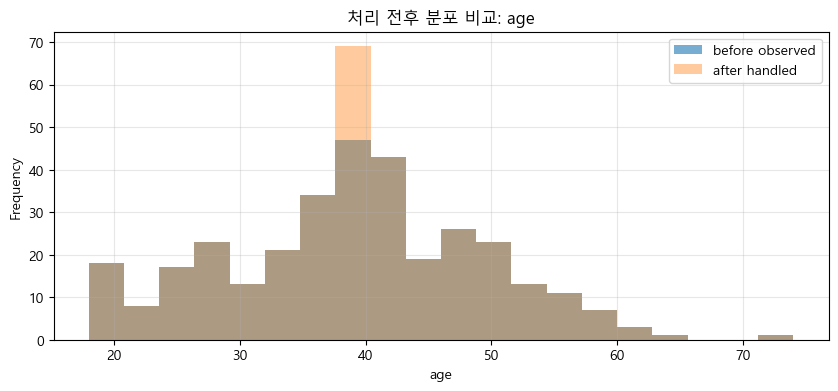

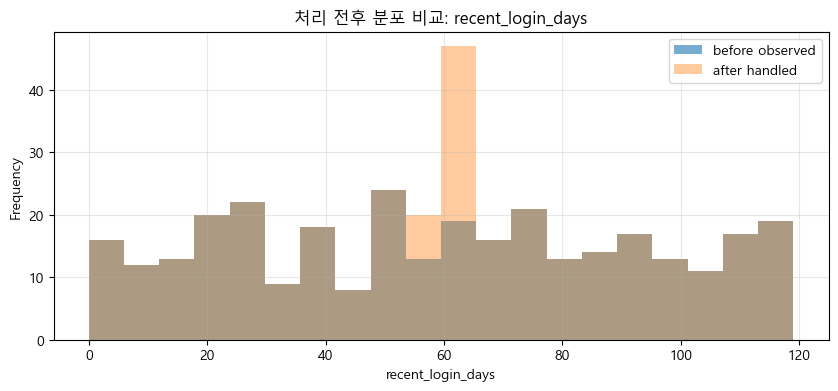

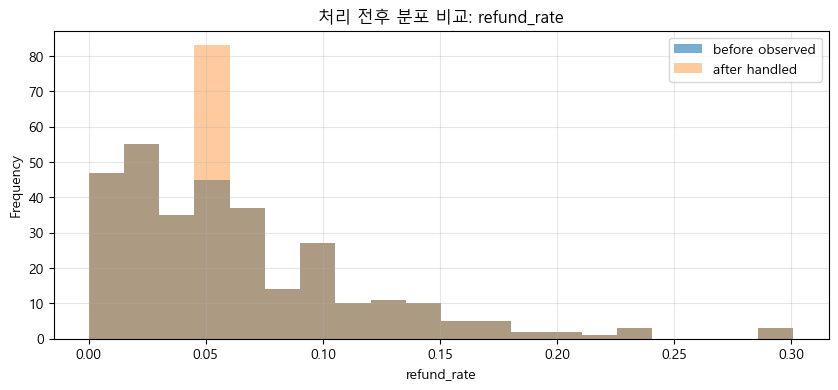

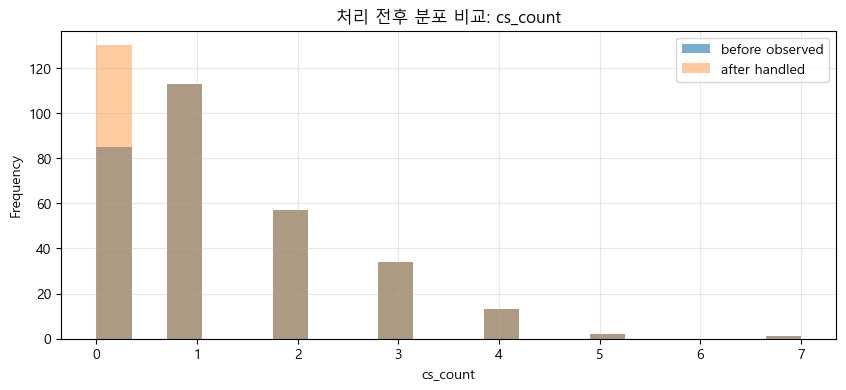

In [11]:
for col in ['age', 'recent_login_days', 'refund_rate', 'cs_count']:
    plt.figure(figsize=(10, 4))
    plt.hist(customer[col].dropna(), bins=20, alpha=0.6, label='before observed')
    plt.hist(customer_handled[col], bins=20, alpha=0.4, label='after handled')
    plt.title(f'처리 전후 분포 비교: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 처리 전후 히스토그램을 비교하여 대체가 분포를 과도하게 왜곡했는지 확인합니다.
# - 대체 후 특정 값에 지나치게 몰리면 모델이 인위적인 패턴을 학습할 수 있습니다.
# - 분포 변화가 크다면 대체 방식이나 그룹별 대체 기준을 다시 검토해야 합니다.
# ------------------------------------------------------------

In [12]:
# 결측 flag와 이탈률의 관계
flag_cols = ['age_missing_flag', 'recent_login_missing_flag', 'refund_rate_missing_flag', 'cs_count_not_applicable_flag']
flag_churn_report = {flag: customer_handled.groupby(flag)['churned'].mean() for flag in flag_cols}
pd.DataFrame(flag_churn_report)

# ------------------------------------------------------------
# 결과 해석:
# - flag 값별 이탈률 차이가 크면 결측 자체가 예측 신호일 수 있습니다.
# - 이 경우 flag를 제거하지 말고 후속 분석이나 모델링 변수로 유지하는 것이 좋습니다.
# - flag와 churned의 관계는 결측을 단순 노이즈로 볼지 의미 있는 정보로 볼지 판단하는 근거가 됩니다.
# ------------------------------------------------------------

,age_missing_flag,recent_login_missing_flag,refund_rate_missing_flag,cs_count_not_applicable_flag
0,0.201220,0.120635,0.217949,0.213115
1,0.318182,1.000000,0.131579,0.177778


In [13]:
missing_final_report = pd.DataFrame({
    'column': customer.columns,
    'before_missing_rate': customer.isna().mean().values,
    'after_missing_rate': customer_handled[customer.columns].isna().mean().values
})
missing_final_report

# ------------------------------------------------------------
# 결과 해석:
# - 처리 후 after_missing_rate가 0에 가까우면 결측 처리가 의도대로 완료된 것입니다.
# - 다만 결측이 사라졌다는 사실만으로 처리가 적절하다고 볼 수는 없습니다.
# - 반드시 처리 전후 분포와 flag의 의미를 함께 검증해야 합니다.
# ------------------------------------------------------------

,column,before_missing_rate,after_missing_rate
0,customer_id,0.000000,0.0
1,segment,0.000000,0.0
2,signup_channel,0.022857,0.0
3,age,0.062857,0.0
4,monthly_spend,0.000000,0.0
5,recent_login_days,0.100000,0.0
6,refund_rate,0.108571,0.0
7,cs_count,0.128571,0.0
8,churned,0.000000,0.0


# Part B. 이상치 처리 워크플로우

## B-1. 이상치 실습 데이터 생성

전자상거래 주문 데이터를 분석하는 상황입니다.

| 컬럼 | 의미 | 품질 이슈 가능성 |
|---|---|---|
| `amount` | 주문 금액 | VIP/기업 결제 고액 주문 가능 |
| `discount_rate` | 할인율 | 0~1 범위 위반은 오류 |
| `refund_rate` | 환불률 | 0~1 범위 위반은 오류 |
| `delivery_days` | 배송 소요일 | 음수는 오류, 큰 값은 이벤트 지연 가능 |
| `age` | 고객 나이 | 음수/120 초과는 오류 |

In [14]:
# ------------------------------------------------------------
# 이상치 실습용 주문 거래 데이터 생성
# ------------------------------------------------------------
# 실제 가능한 이상치와 도메인상 불가능한 오류를 함께 넣습니다.
# ------------------------------------------------------------

m = 500
orders = pd.DataFrame({
    'order_id': np.arange(50001, 50001 + m),
    'customer_type': rng.choice(['Retail', 'VIP', 'Corporate'], size=m, p=[0.78, 0.15, 0.07]),
    'amount': np.round(rng.lognormal(mean=11.0, sigma=0.65, size=m), -2),
    'quantity': rng.poisson(3, size=m) + 1,
    'discount_rate': np.round(rng.beta(1.5, 8, size=m), 3),
    'refund_rate': np.round(rng.beta(1.0, 18, size=m), 3),
    'delivery_days': rng.poisson(3, size=m) + 1,
    'age': np.round(rng.normal(38, 12, size=m)).astype(int),
    'event_period': rng.choice([0, 1], size=m, p=[0.85, 0.15])
})
orders.loc[orders['customer_type'] == 'VIP', 'amount'] *= 2.0
orders.loc[orders['customer_type'] == 'Corporate', 'amount'] *= 3.5
orders['amount'] = orders['amount'].round(-2)
orders.loc[orders['event_period'] == 1, 'delivery_days'] += rng.integers(2, 8, size=(orders['event_period'] == 1).sum())

# 실제 가능성이 있는 고액 주문
vip_like_idx = rng.choice(orders.index, size=5, replace=False)
orders.loc[vip_like_idx, 'amount'] = [3800000, 4200000, 5100000, 6900000, 8500000]
orders.loc[vip_like_idx, 'customer_type'] = rng.choice(['VIP', 'Corporate'], size=5)
orders.loc[vip_like_idx, 'event_period'] = 1

# 명백한 오류 주입
orders.loc[rng.choice(orders.index, size=2, replace=False), 'age'] = [-3, 142]
orders.loc[rng.choice(orders.index, size=2, replace=False), 'refund_rate'] = [1.2, -0.1]
orders.loc[rng.choice(orders.index, size=2, replace=False), 'discount_rate'] = [1.4, -0.2]
orders.loc[rng.choice(orders.index, size=1, replace=False), 'delivery_days'] = -5
orders.loc[rng.choice(orders.index, size=4, replace=False), 'amount'] = 0

orders.head()

# ------------------------------------------------------------
# 결과 해석:
# - 주문 거래 데이터에는 실제 가능한 고액 주문과 도메인상 불가능한 오류가 함께 포함되어 있습니다.
# - 이상치 실습의 핵심은 큰 값을 무조건 제거하지 않고 오류와 실제 이상치를 구분하는 것입니다.
# - amount, refund_rate, discount_rate, delivery_days, age가 주요 품질 진단 대상입니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,quantity,discount_rate,refund_rate,delivery_days,age,event_period
0,50001,VIP,74400.0,3,0.152,0.002,4,20,0
1,50002,Retail,23500.0,6,0.290,0.064,7,44,1
2,50003,Retail,224100.0,6,0.411,0.065,11,33,0
3,50004,VIP,146000.0,9,0.296,0.054,3,33,0
4,50005,Retail,81800.0,5,0.179,0.058,4,29,0


## B-2. 1단계: 도메인 규칙 기반 오류 탐지

이상치를 보기 전에 도메인상 불가능한 **오류(error)**를 먼저 찾아야 합니다.

In [15]:
rule_violations = pd.DataFrame({
    'age_invalid': ~orders['age'].between(0, 120),
    'refund_rate_invalid': ~orders['refund_rate'].between(0, 1),
    'discount_rate_invalid': ~orders['discount_rate'].between(0, 1),
    'delivery_days_invalid': orders['delivery_days'] < 0,
    'amount_invalid': orders['amount'] < 0
})
rule_violations.sum().sort_values(ascending=False)

# ------------------------------------------------------------
# 결과 해석:
# - 도메인 규칙 위반 개수는 명백한 오류 후보의 수를 보여줍니다.
# - 예를 들어 환불률이나 할인율이 0~1 범위를 벗어나면 정의상 오류입니다.
# - 이 단계는 통계적 이상치 탐지보다 먼저 수행해야 합니다.
# ------------------------------------------------------------

age_invalid              2
refund_rate_invalid      2
discount_rate_invalid    2
delivery_days_invalid    1
amount_invalid           0
dtype: int64

In [16]:
# 규칙 위반 행 확인
orders[rule_violations.any(axis=1)]

# ------------------------------------------------------------
# 결과 해석:
# - 출력된 행은 도메인 규칙을 위반한 주문입니다.
# - 이 행들은 단순 이상치가 아니라 원천 데이터 오류, 입력 오류, 변환 오류일 가능성이 큽니다.
# - 실무에서는 삭제 전에 원천 시스템 재확인 또는 담당자 확인이 필요합니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,quantity,discount_rate,refund_rate,delivery_days,age,event_period
167,50168,Retail,99700.0,6,-0.200,0.019,6,54,0
288,50289,Retail,107300.0,2,0.028,0.039,7,-3,0
366,50367,Retail,30700.0,4,0.249,0.113,-5,40,0
375,50376,Retail,30000.0,4,0.172,-0.100,2,50,0
431,50432,Retail,101500.0,3,0.063,1.200,11,70,1
465,50466,Retail,86200.0,4,0.240,0.002,5,142,0
484,50485,VIP,95800.0,2,1.400,0.055,4,31,0


## B-3. 2단계: 이상치 탐지 1 - IQR 그래프

IQR 방식은 사분위수를 이용합니다.

- Q1: 25% 지점
- Q3: 75% 지점
- IQR = Q3 - Q1
- 하한 = Q1 - 1.5 × IQR
- 상한 = Q3 + 1.5 × IQR

상한보다 크거나 하한보다 작은 값은 이상치 **후보**입니다.

In [17]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return lower, upper, q1, q3, iqr

amount = orders['amount']
lower_iqr, upper_iqr, q1, q3, iqr = iqr_bounds(amount)

pd.Series({
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'lower_bound': lower_iqr,
    'upper_bound': upper_iqr,
    'outlier_count': ((amount < lower_iqr) | (amount > upper_iqr)).sum()
})

# ------------------------------------------------------------
# 결과 해석:
# - IQR 방식은 사분위수 기반으로 이상치 후보를 탐지합니다.
# - outlier_count는 IQR 기준 상한 또는 하한을 벗어난 데이터 개수입니다.
# - IQR은 분포 가정이 약한 편이지만, 탐지된 값을 무조건 제거하는 기준은 아닙니다.
# ------------------------------------------------------------

Q1                40950.0
Q3               113650.0
IQR               72700.0
lower_bound      -68100.0
upper_bound      222700.0
outlier_count        34.0
dtype: float64

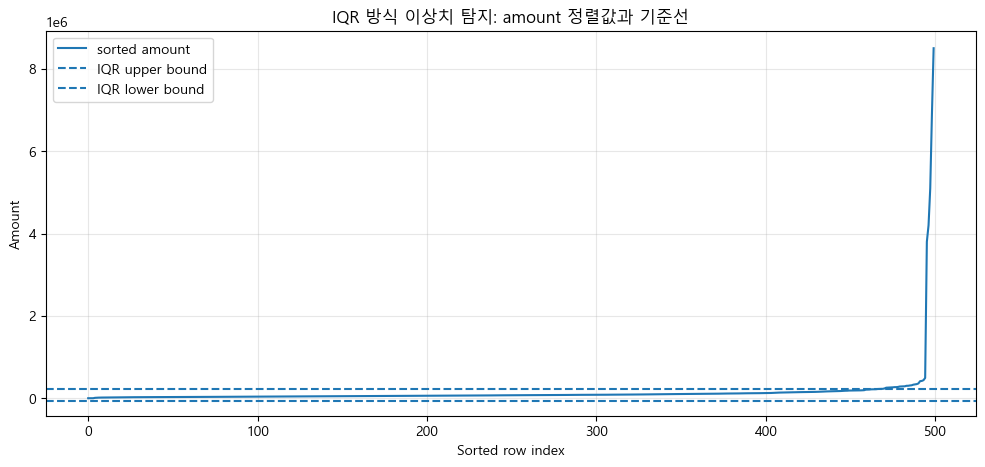

In [18]:
# 탐지 그래프 1: IQR 기준선 그래프
amount_sorted = amount.sort_values().reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.plot(amount_sorted.index, amount_sorted.values, label='sorted amount')
plt.axhline(upper_iqr, linestyle='--', label='IQR upper bound')
plt.axhline(lower_iqr, linestyle='--', label='IQR lower bound')
plt.title('IQR 방식 이상치 탐지: amount 정렬값과 기준선')
plt.xlabel('Sorted row index')
plt.ylabel('Amount')
plt.legend()
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 정렬된 amount 값이 IQR 상한선을 넘어 급격히 증가하는 구간은 이상치 후보입니다.
# - 오른쪽 끝의 큰 값들은 고액 주문일 수 있으므로 고객 유형과 이벤트 여부를 함께 확인해야 합니다.
# - 이 그래프는 이상치 후보의 위치와 규모를 직관적으로 보여줍니다.
# ------------------------------------------------------------

## B-4. 3단계: 이상치 탐지 2 - Z-score 그래프

Z-score는 평균과 표준편차를 기준으로 값이 평균에서 얼마나 떨어져 있는지 봅니다. 일반적으로 `|z| > 3`이면 이상치 후보로 봅니다.

In [19]:
orders['amount_zscore'] = (orders['amount'] - orders['amount'].mean()) / orders['amount'].std(ddof=0)
orders['amount_zscore_outlier_flag'] = (orders['amount_zscore'].abs() > 3).astype(int)
orders[['order_id', 'customer_type', 'amount', 'amount_zscore', 'amount_zscore_outlier_flag']].sort_values('amount_zscore', ascending=False).head(10)

# ------------------------------------------------------------
# 결과 해석:
# - Z-score는 평균에서 몇 표준편차 떨어져 있는지를 나타냅니다.
# - 일반적으로 절댓값 3을 넘으면 이상치 후보로 보지만, amount처럼 긴 꼬리 분포에서는 해석에 주의해야 합니다.
# - Z-score 결과는 IQR 결과와 교차 확인하는 보조 지표로 사용하는 것이 좋습니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,amount_zscore,amount_zscore_outlier_flag
457,50458,VIP,8500000.0,14.170176,1
475,50476,Corporate,6900000.0,11.456217,1
41,50042,Corporate,5100000.0,8.403013,1
221,50222,Corporate,4200000.0,6.876411,1
239,50240,Corporate,3800000.0,6.197921,1
159,50160,Retail,492300.0,0.587319,0
278,50279,VIP,437800.0,0.494875,0
96,50097,Retail,419800.0,0.464343,0
399,50400,VIP,414000.0,0.454505,0
246,50247,VIP,358600.0,0.360534,0


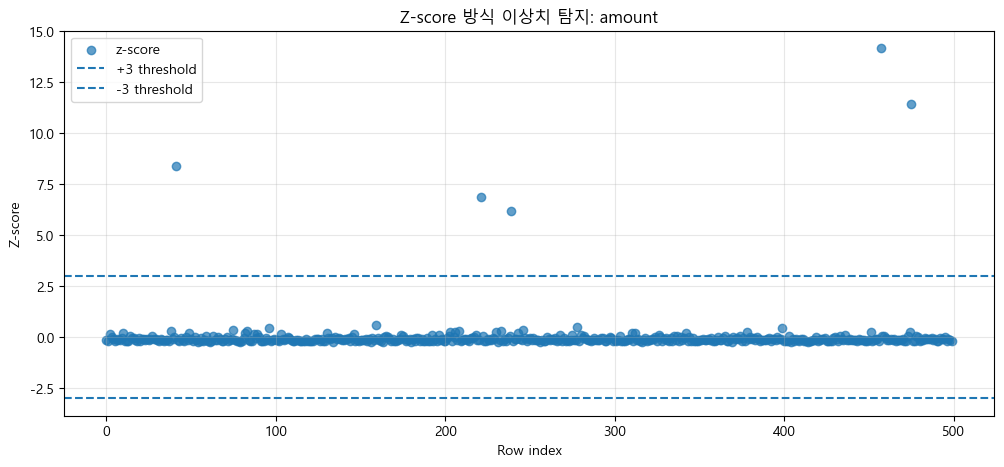

In [20]:
# 탐지 그래프 2: Z-score 그래프
plt.figure(figsize=(12, 5))
plt.scatter(orders.index, orders['amount_zscore'], alpha=0.7, label='z-score')
plt.axhline(3, linestyle='--', label='+3 threshold')
plt.axhline(-3, linestyle='--', label='-3 threshold')
plt.title('Z-score 방식 이상치 탐지: amount')
plt.xlabel('Row index')
plt.ylabel('Z-score')
plt.legend()
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 점이 +3 또는 -3 기준선을 넘으면 Z-score 기준 이상치 후보입니다.
# - 대부분의 주문이 0 근처에 있고 일부 점만 크게 벗어나면 극단적인 주문이 존재한다는 의미입니다.
# - 기준선을 넘은 값이 실제 오류인지, VIP/기업 주문인지 추가 확인해야 합니다.
# ------------------------------------------------------------

## B-5. 4단계: 이상치 탐지 3 - 히스토그램

히스토그램은 하나의 수치형 변수가 어떤 분포를 가지는지 보여줍니다. 이상치 탐지에서는 한쪽 꼬리, 특정 값 집중, 비정상적 분포를 확인합니다.

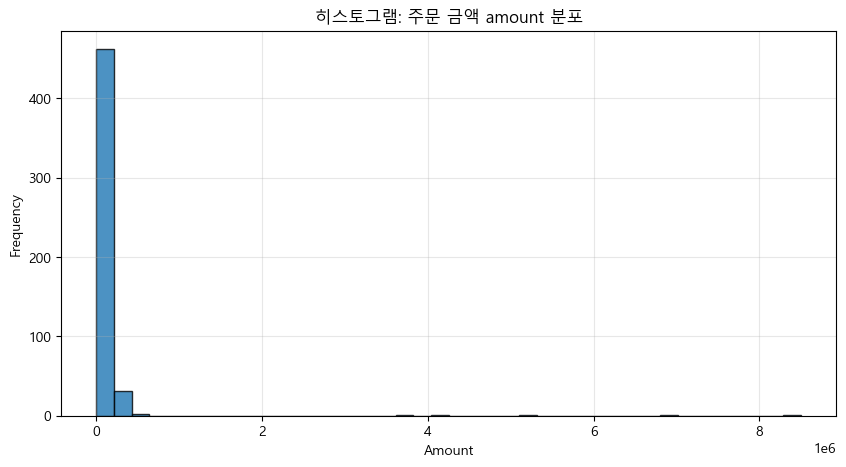

In [21]:
# 탐지 그래프 3: 히스토그램
plt.figure(figsize=(10, 5))
plt.hist(orders['amount'], bins=40, edgecolor='black', alpha=0.8)
plt.title('히스토그램: 주문 금액 amount 분포')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 히스토그램은 amount 분포의 모양을 보여줍니다.
# - 오른쪽 꼬리가 길면 평균보다 중앙값이 대표값으로 더 적절할 수 있습니다.
# - 분포가 심하게 치우친 경우 로그변환이나 클리핑을 고려할 수 있습니다.
# ------------------------------------------------------------

## B-6. 5단계: 이상치 탐지 4 - 박스플롯

박스플롯은 중앙값, 사분위수, IQR 기준 이상치 후보를 한눈에 보여줍니다.

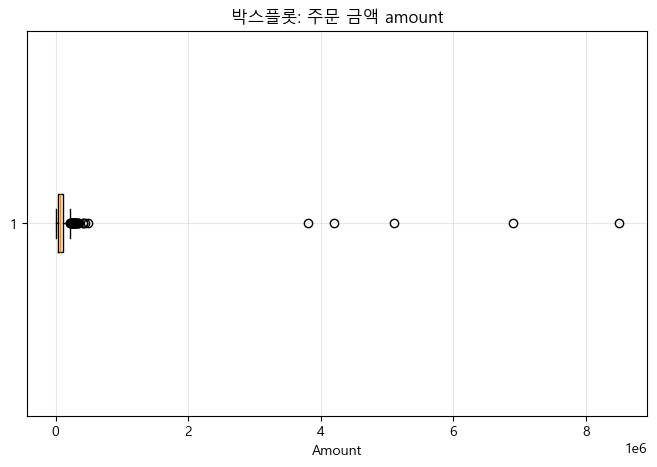

In [22]:
# 탐지 그래프 4: 박스플롯
plt.figure(figsize=(8, 5))
plt.boxplot(orders['amount'], vert=False)
plt.title('박스플롯: 주문 금액 amount')
plt.xlabel('Amount')
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 박스플롯은 중앙값, 사분위수, IQR 기준 이상치 후보를 한눈에 보여줍니다.
# - 수염 바깥의 점은 IQR 기준 이상치 후보입니다.
# - 후보 값이 업무적으로 설명 가능하면 제거보다 태깅 또는 변환이 더 적절할 수 있습니다.
# ------------------------------------------------------------

## B-7. 6단계: 탐지 결과 종합

탐지 방법별 플래그를 합쳐 우선 검토 대상을 만듭니다. 탐지는 조치가 아니라 **검토 후보 선정**입니다.

In [23]:
orders['amount_iqr_outlier_flag'] = ((orders['amount'] < lower_iqr) | (orders['amount'] > upper_iqr)).astype(int)

detection_summary = pd.DataFrame({
    'method': ['IQR', 'Z-score', 'Domain rule violation'],
    'detected_count': [
        int(orders['amount_iqr_outlier_flag'].sum()),
        int(orders['amount_zscore_outlier_flag'].sum()),
        int(rule_violations.any(axis=1).sum())
    ]
})
detection_summary

# ------------------------------------------------------------
# 결과 해석:
# - 탐지 방법별 이상치 후보 개수를 비교할 수 있습니다.
# - IQR, Z-score, 도메인 규칙은 서로 다른 기준이므로 탐지 개수가 다르게 나올 수 있습니다.
# - 여러 방법에서 동시에 탐지된 값은 우선 검토 대상입니다.
# ------------------------------------------------------------

,method,detected_count
0,IQR,34
1,Z-score,5
2,Domain rule violation,7


In [24]:
amount_outlier_candidates = orders[(orders['amount_iqr_outlier_flag'] == 1) | (orders['amount_zscore_outlier_flag'] == 1)].copy()
amount_outlier_candidates[['order_id','customer_type','amount','quantity','discount_rate','refund_rate','delivery_days','event_period','amount_iqr_outlier_flag','amount_zscore_outlier_flag']].sort_values('amount', ascending=False).head(20)

# ------------------------------------------------------------
# 결과 해석:
# - 이 표는 amount 이상치 후보 주문의 세부 정보를 보여줍니다.
# - customer_type과 event_period를 함께 보면 고액 주문이 설명 가능한지 판단할 수 있습니다.
# - VIP 또는 Corporate 주문이라면 실제 비즈니스 신호일 가능성이 있으므로 제거에 신중해야 합니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,quantity,discount_rate,refund_rate,delivery_days,event_period,amount_iqr_outlier_flag,amount_zscore_outlier_flag
457,50458,VIP,8500000.0,2,0.099,0.148,8,1,1,1
475,50476,Corporate,6900000.0,6,0.065,0.007,3,1,1,1
41,50042,Corporate,5100000.0,4,0.019,0.102,3,1,1,1
221,50222,Corporate,4200000.0,5,0.282,0.037,2,1,1,1
239,50240,Corporate,3800000.0,1,0.149,0.085,4,1,1,1
159,50160,Retail,492300.0,6,0.020,0.020,9,0,1,0
278,50279,VIP,437800.0,4,0.280,0.184,3,0,1,0
96,50097,Retail,419800.0,5,0.190,0.046,7,1,1,0
399,50400,VIP,414000.0,3,0.008,0.068,5,0,1,0
246,50247,VIP,358600.0,2,0.043,0.033,4,0,1,0


## B-8. 7단계: 오류와 이상치 구분 의사결정

| 유형 | 예시 | 처리 방향 |
|---|---|---|
| 명백한 오류 | 음수 나이, 환불률 1 초과, 배송일 음수 | 수정, 제거, 재수집, 결측 처리 |
| 실제 가능한 이상치 | VIP 고액 구매, 이벤트 기간 배송 지연 | 제거하지 않고 태깅하거나 변환 |
| 상황 의존 값 | 금액 0원 주문 | 무료 샘플, 쿠폰 여부 확인 후 태깅 |
| 분석 목적상 왜곡 유발 값 | 모델 학습에서 과도한 영향 | 클리핑, 로그변환, robust scaling 고려 |

In [25]:
outlier_decision = pd.DataFrame([
    {'issue': 'age < 0 or age > 120', 'type': 'error', 'decision': 'replace + flag', 'action': 'invalid_age_flag 생성 후 NaN으로 바꾸고 중앙값 대체'},
    {'issue': 'refund_rate < 0 or > 1', 'type': 'error', 'decision': 'replace + flag', 'action': 'invalid_refund_rate_flag 생성 후 NaN으로 바꾸고 중앙값 대체'},
    {'issue': 'discount_rate < 0 or > 1', 'type': 'error', 'decision': 'replace + flag', 'action': 'invalid_discount_rate_flag 생성 후 NaN으로 바꾸고 중앙값 대체'},
    {'issue': 'delivery_days < 0', 'type': 'error', 'decision': 'replace + flag', 'action': 'invalid_delivery_days_flag 생성 후 NaN으로 바꾸고 중앙값 대체'},
    {'issue': 'amount very high', 'type': 'outlier', 'decision': 'tag + log transform + optional clipping', 'action': 'amount_outlier_flag, log1p 변수, clipping 변수 생성'},
    {'issue': 'amount = 0', 'type': 'context-dependent', 'decision': 'tag', 'action': 'zero_amount_flag 생성'}
])
outlier_decision

# ------------------------------------------------------------
# 결과 해석:
# - 이 의사결정 표는 오류와 이상치의 조치 방법을 구분합니다.
# - 도메인상 불가능한 값은 error로 보고 flag 후 대체하거나 재수집 대상으로 둡니다.
# - 실제 가능한 고액 주문은 outlier로 보고 원본을 보존하면서 태깅, 로그변환, 클리핑 변수를 만듭니다.
# ------------------------------------------------------------

,issue,type,decision,action
0,age < 0 or age > 120,error,replace + flag,invalid_age_flag 생성 후 NaN으로 바꾸고 중앙값 대체
1,refund_rate < 0 or > 1,error,replace + flag,invalid_refund_rate_flag 생성 후 NaN으로 바꾸고 중앙값 대체
2,discount_rate < 0 or > 1,error,replace + flag,invalid_discount_rate_flag 생성 후 NaN으로 바꾸고 중앙값 대체
3,delivery_days < 0,error,replace + flag,invalid_delivery_days_flag 생성 후 NaN으로 바꾸고 중앙값 대체
4,amount very high,outlier,tag + log transform + optional clipping,"amount_outlier_flag, log1p 변수, clipping 변수 생성"
5,amount = 0,context-dependent,tag,zero_amount_flag 생성


## B-9. 조치 방법 1 - 제거(Removal)

제거는 단순하지만 정보 손실 위험이 있습니다. 명백한 오류이거나 원천 확인 결과 잘못된 값일 때만 신중하게 사용합니다.

In [26]:
orders_actions = orders.copy()
orders_actions['domain_error_flag'] = rule_violations.any(axis=1).astype(int)
remove_candidates = orders_actions[orders_actions['domain_error_flag'] == 1]
print('제거 또는 재수집 검토 대상 행 수:', len(remove_candidates))
remove_candidates.head(10)

# ------------------------------------------------------------
# 결과 해석:
# - domain_error_flag가 1인 행은 제거 또는 재수집을 검토할 대상입니다.
# - 이 단계에서는 바로 삭제하지 않고 후보 목록을 확인하는 것이 중요합니다.
# - 오류 행의 다른 컬럼에 유효한 정보가 많다면 행 전체 삭제보다 값 단위 대체가 나을 수 있습니다.
# ------------------------------------------------------------

제거 또는 재수집 검토 대상 행 수: 7


,order_id,customer_type,amount,quantity,discount_rate,refund_rate,delivery_days,age,event_period,amount_zscore,amount_zscore_outlier_flag,amount_iqr_outlier_flag,domain_error_flag
167,50168,Retail,99700.0,6,-0.200,0.019,6,54,0,-0.078619,0,0,1
288,50289,Retail,107300.0,2,0.028,0.039,7,-3,0,-0.065727,0,0,1
366,50367,Retail,30700.0,4,0.249,0.113,-5,40,0,-0.195658,0,0,1
375,50376,Retail,30000.0,4,0.172,-0.100,2,50,0,-0.196845,0,0,1
431,50432,Retail,101500.0,3,0.063,1.200,11,70,1,-0.075565,0,0,1
465,50466,Retail,86200.0,4,0.240,0.002,5,142,0,-0.101518,0,0,1
484,50485,VIP,95800.0,2,1.400,0.055,4,31,0,-0.085234,0,0,1


In [27]:
# 제거 예시: 실무에서는 원천 확인 후 결정합니다.
orders_removed = orders_actions[orders_actions['domain_error_flag'] == 0].copy()
print('원본 행 수:', len(orders_actions))
print('오류 행 제거 후 행 수:', len(orders_removed))

# ------------------------------------------------------------
# 결과 해석:
# - 오류 행 제거 후 행 수가 줄어듭니다.
# - 제거는 단순하지만 정보 손실이 발생하므로 결측률이나 오류율이 낮고 근거가 명확할 때만 사용합니다.
# - 실무에서는 제거 전후 주요 지표가 크게 변하지 않는지 확인해야 합니다.
# ------------------------------------------------------------

원본 행 수: 500
오류 행 제거 후 행 수: 493


## B-10. 조치 방법 2 - 클리핑(Clipping)

클리핑은 값을 제거하지 않고 상한/하한으로 제한합니다. 원본은 보존하고 파생 변수를 생성하는 방식이 안전합니다.

In [28]:
orders_actions['amount_clipped_iqr'] = orders_actions['amount'].clip(lower=0, upper=upper_iqr)
orders_actions[['amount', 'amount_clipped_iqr']].describe()

# ------------------------------------------------------------
# 결과 해석:
# - amount_clipped_iqr는 IQR 상한을 넘는 값을 상한값으로 제한한 파생 변수입니다.
# - 원본 amount를 삭제하지 않고 별도 변수를 만든 점이 중요합니다.
# - 클리핑은 극단값 영향은 줄이지만 큰 주문 간 차이를 잃을 수 있습니다.
# ------------------------------------------------------------

,amount,amount_clipped_iqr
count,500.000,500.000000
mean,146049.200,86681.600000
std,590135.033,57575.017035
min,0.000,0.000000
25%,40950.000,40950.000000
50%,72650.000,72650.000000
75%,113650.000,113650.000000
max,8500000.000,222700.000000


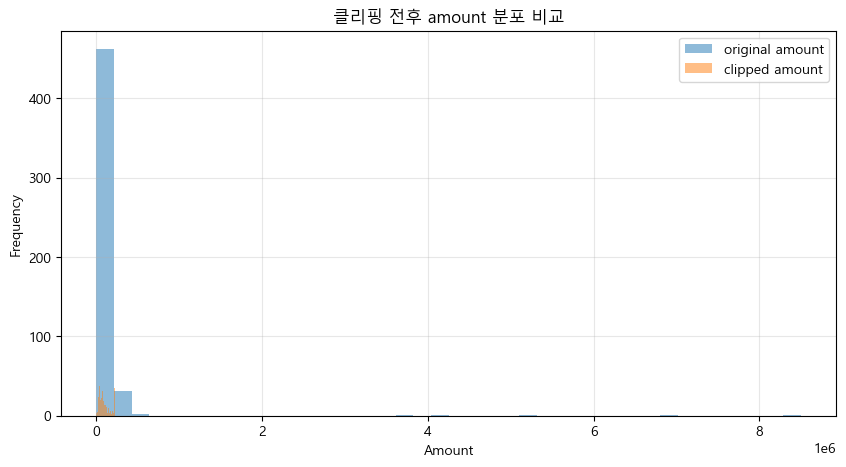

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(orders_actions['amount'], bins=40, alpha=0.5, label='original amount')
plt.hist(orders_actions['amount_clipped_iqr'], bins=40, alpha=0.5, label='clipped amount')
plt.title('클리핑 전후 amount 분포 비교')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 클리핑 후 분포는 원본보다 오른쪽 꼬리의 영향이 줄어듭니다.
# - 상한값 근처에 값이 몰리면 클리핑이 강하게 적용되었다는 의미입니다.
# - 클리핑 변수는 모델링용으로 사용하고, 원본 금액은 비즈니스 해석용으로 보존하는 것이 좋습니다.
# ------------------------------------------------------------

## B-11. 조치 방법 3 - 대체(Imputation)

도메인상 불가능한 값을 결측으로 바꾼 뒤 중앙값 등으로 대체할 수 있습니다. 대체 전에는 반드시 오류 flag를 남깁니다.

In [30]:
orders_imputed = orders_actions.copy()
orders_imputed['invalid_age_flag'] = (~orders_imputed['age'].between(0, 120)).astype(int)
orders_imputed['invalid_refund_rate_flag'] = (~orders_imputed['refund_rate'].between(0, 1)).astype(int)
orders_imputed['invalid_discount_rate_flag'] = (~orders_imputed['discount_rate'].between(0, 1)).astype(int)
orders_imputed['invalid_delivery_days_flag'] = (orders_imputed['delivery_days'] < 0).astype(int)

orders_imputed.loc[orders_imputed['invalid_age_flag'] == 1, 'age'] = np.nan
orders_imputed.loc[orders_imputed['invalid_refund_rate_flag'] == 1, 'refund_rate'] = np.nan
orders_imputed.loc[orders_imputed['invalid_discount_rate_flag'] == 1, 'discount_rate'] = np.nan
orders_imputed.loc[orders_imputed['invalid_delivery_days_flag'] == 1, 'delivery_days'] = np.nan

for col in ['age', 'refund_rate', 'discount_rate', 'delivery_days']:
    orders_imputed[col] = orders_imputed[col].fillna(orders_imputed[col].median())

orders_imputed[['invalid_age_flag','invalid_refund_rate_flag','invalid_discount_rate_flag','invalid_delivery_days_flag']].sum()

# ------------------------------------------------------------
# 결과 해석:
# - 도메인 오류값을 NaN으로 바꾼 후 중앙값으로 대체했습니다.
# - invalid_*_flag는 어떤 값이 원래 오류였는지를 추적하기 위한 변수입니다.
# - 대체 후에도 오류 발생 사실을 보존해야 품질 모니터링과 모델 해석이 가능합니다.
# ------------------------------------------------------------

invalid_age_flag              2
invalid_refund_rate_flag      2
invalid_discount_rate_flag    2
invalid_delivery_days_flag    1
dtype: int64

## B-12. 조치 방법 4 - 로그변환(Log Transform)

주문 금액처럼 오른쪽 꼬리가 긴 분포는 로그변환이 유용합니다. `log1p(x)`는 `log(1+x)`이므로 0도 처리할 수 있습니다.

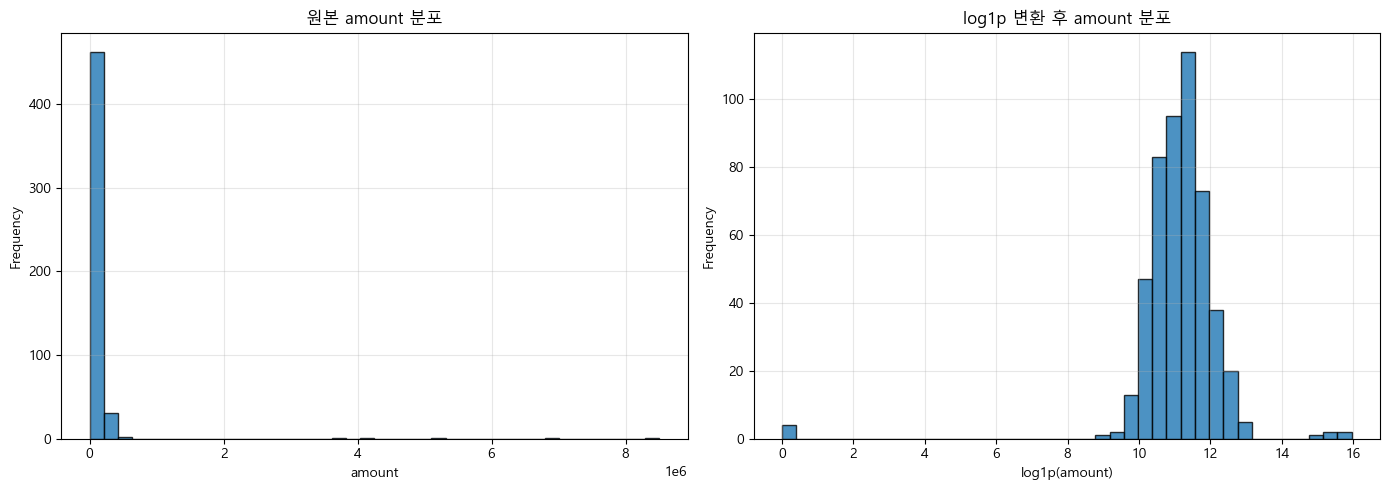

In [31]:
orders_imputed['amount_log1p'] = np.log1p(orders_imputed['amount'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(orders_imputed['amount'], bins=40, edgecolor='black', alpha=0.8)
axes[0].set_title('원본 amount 분포')
axes[0].set_xlabel('amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(orders_imputed['amount_log1p'], bins=40, edgecolor='black', alpha=0.8)
axes[1].set_title('log1p 변환 후 amount 분포')
axes[1].set_xlabel('log1p(amount)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 로그변환 후 분포는 원본보다 오른쪽 꼬리가 완화됩니다.
# - 금액처럼 0 이상이고 편향이 큰 변수에는 log1p 변환이 자주 사용됩니다.
# - 다만 로그값은 원 단위 해석이 어렵기 때문에 해석용 원본 변수도 함께 보관해야 합니다.
# ------------------------------------------------------------

## B-13. 조치 방법 5 - 별도 태깅(Tagging)

실제 가능한 이상치를 제거하지 않고 태깅하면 중요한 신호를 보존할 수 있습니다.

In [32]:
orders_imputed['amount_iqr_outlier_flag'] = ((orders_imputed['amount'] < lower_iqr) | (orders_imputed['amount'] > upper_iqr)).astype(int)
orders_imputed['zero_amount_flag'] = (orders_imputed['amount'] == 0).astype(int)
orders_imputed['high_value_context_flag'] = (
    (orders_imputed['amount_iqr_outlier_flag'] == 1) &
    (orders_imputed['customer_type'].isin(['VIP', 'Corporate']) | (orders_imputed['event_period'] == 1))
).astype(int)
orders_imputed[['amount_iqr_outlier_flag', 'zero_amount_flag', 'high_value_context_flag']].sum()

# ------------------------------------------------------------
# 결과 해석:
# - amount_iqr_outlier_flag는 통계적 이상치 후보를 표시합니다.
# - zero_amount_flag는 무료 샘플이나 쿠폰 적용 가능성이 있는 주문을 추적하기 위한 변수입니다.
# - high_value_context_flag는 고액 주문이 VIP/기업/이벤트 맥락에서 설명 가능한지 나타냅니다.
# ------------------------------------------------------------

amount_iqr_outlier_flag    34
zero_amount_flag            4
high_value_context_flag    26
dtype: int64

In [33]:
orders_imputed[orders_imputed['amount_iqr_outlier_flag'] == 1][['order_id','customer_type','amount','amount_log1p','amount_clipped_iqr','event_period','high_value_context_flag']].sort_values('amount', ascending=False).head(20)

# ------------------------------------------------------------
# 결과 해석:
# - 고액 주문 후보 목록에서 context flag가 1이면 실제 가능한 이상치일 가능성이 높습니다.
# - 이런 값은 제거보다 별도 태깅 후 분석에 활용하는 것이 적절합니다.
# - context flag가 0인 고액 주문은 원천 데이터 확인 우선순위가 높습니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,amount_log1p,amount_clipped_iqr,event_period,high_value_context_flag
457,50458,VIP,8500000.0,15.955577,222700.0,1,1
475,50476,Corporate,6900000.0,15.747032,222700.0,1,1
41,50042,Corporate,5100000.0,15.444751,222700.0,1,1
221,50222,Corporate,4200000.0,15.250595,222700.0,1,1
239,50240,Corporate,3800000.0,15.150512,222700.0,1,1
159,50160,Retail,492300.0,13.106846,222700.0,0,0
278,50279,VIP,437800.0,12.989520,222700.0,0,1
96,50097,Retail,419800.0,12.947536,222700.0,1,1
399,50400,VIP,414000.0,12.933624,222700.0,0,1
246,50247,VIP,358600.0,12.789966,222700.0,0,1


## B-14. 조치 방법별 결과 비교

| 방법 | 장점 | 단점 |
|---|---|---|
| 제거 | 단순하고 명확 | 정보 손실 위험 |
| 클리핑 | 극단값 영향 완화 | 실제 큰 값의 차이 손실 |
| 대체 | 오류값 보정 가능 | 대체 근거가 약하면 왜곡 |
| 로그변환 | 긴 꼬리 완화 | 원 단위 해석 어려움 |
| 태깅 | 신호 보존 | 추가 해석 필요 |

In [34]:
comparison_summary = pd.DataFrame({
    'original_amount': orders_actions['amount'].describe(),
    'removed_errors_amount': orders_removed['amount'].describe(),
    'clipped_amount': orders_actions['amount_clipped_iqr'].describe(),
    'log1p_amount': orders_imputed['amount_log1p'].describe()
})
comparison_summary

# ------------------------------------------------------------
# 결과 해석:
# - 원본, 오류 제거, 클리핑, 로그변환의 요약 통계를 비교합니다.
# - 클리핑은 최대값과 표준편차를 줄이고, 로그변환은 스케일 자체를 바꿉니다.
# - 처리 방법 선택은 분석 목적과 모델 민감도에 따라 달라집니다.
# ------------------------------------------------------------

,original_amount,removed_errors_amount,clipped_amount,log1p_amount
count,500.000,4.930000e+02,500.000000,500.000000
mean,146049.200,1.470049e+05,86681.600000,11.126221
std,590135.033,5.942517e+05,57575.017035,1.286764
min,0.000,0.000000e+00,0.000000,0.000000
25%,40950.000,4.100000e+04,40950.000000,10.620129
50%,72650.000,7.240000e+04,72650.000000,11.193422
75%,113650.000,1.138000e+05,113650.000000,11.640887
max,8500000.000,8.500000e+06,222700.000000,15.955577


C:\Users\yhkim\AppData\Local\Temp\ipykernel_15816\1044736277.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([orders_actions['amount'], orders_actions['amount_clipped_iqr']], labels=['original', 'clipped'])


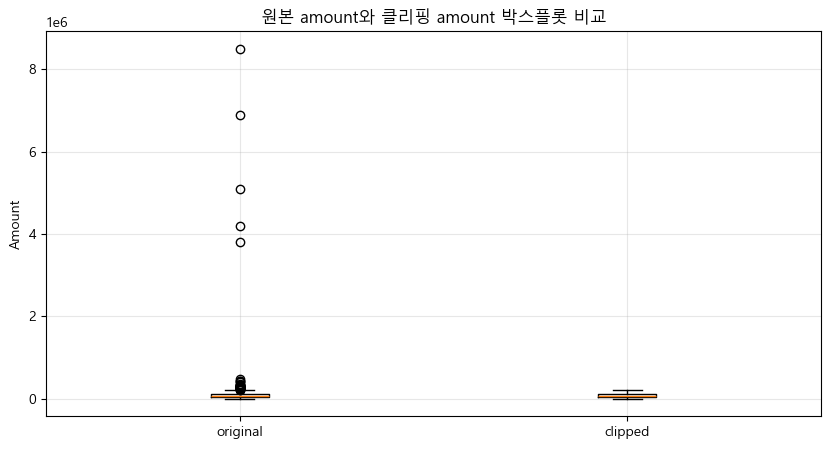

C:\Users\yhkim\AppData\Local\Temp\ipykernel_15816\1044736277.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(orders_imputed['amount_log1p'], labels=['log1p(amount)'])


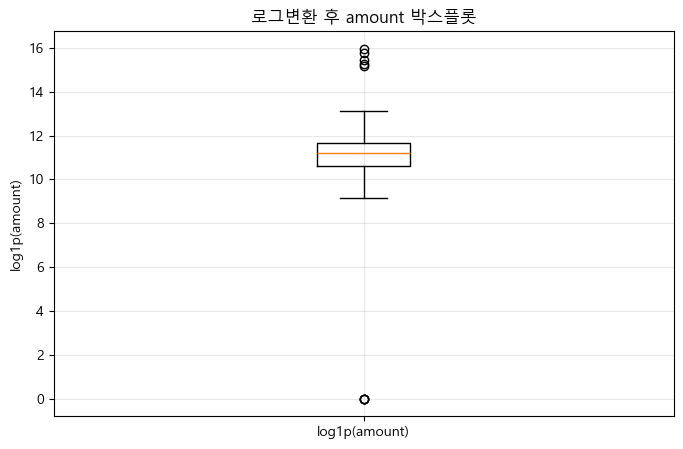

In [35]:
plt.figure(figsize=(10, 5))
plt.boxplot([orders_actions['amount'], orders_actions['amount_clipped_iqr']], labels=['original', 'clipped'])
plt.title('원본 amount와 클리핑 amount 박스플롯 비교')
plt.ylabel('Amount')
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(orders_imputed['amount_log1p'], labels=['log1p(amount)'])
plt.title('로그변환 후 amount 박스플롯')
plt.ylabel('log1p(amount)')
plt.show()

# ------------------------------------------------------------
# 결과 해석:
# - 박스플롯 비교를 통해 클리핑이 극단값 영향을 얼마나 줄였는지 확인합니다.
# - 로그변환 박스플롯은 원본 금액과 단위가 다르므로 별도로 해석해야 합니다.
# - 시각화는 처리 전후 변화가 과도한지 검증하는 핵심 절차입니다.
# ------------------------------------------------------------

## B-15. 최종 이상치 처리 데이터셋과 품질 리포트

실무에서는 하나의 정답 처리만 고집하기보다 원본, 파생 변수, flag를 함께 보관하는 방식이 안전합니다.

In [36]:
final_orders = orders_imputed[[
    'order_id','customer_type','amount','amount_clipped_iqr','amount_log1p',
    'amount_iqr_outlier_flag','amount_zscore_outlier_flag','zero_amount_flag','high_value_context_flag',
    'quantity','discount_rate','refund_rate','delivery_days','age','event_period',
    'invalid_age_flag','invalid_refund_rate_flag','invalid_discount_rate_flag','invalid_delivery_days_flag'
]].copy()
final_orders.head()

# ------------------------------------------------------------
# 결과 해석:
# - final_orders는 이상치 처리 결과를 반영한 최종 분석용 데이터셋입니다.
# - 원본 금액, 클리핑 금액, 로그변환 금액, flag 변수가 함께 포함되어 있습니다.
# - 이 구조는 분석 목적에 따라 원본과 가공 변수를 선택적으로 사용할 수 있게 해줍니다.
# ------------------------------------------------------------

,order_id,customer_type,amount,amount_clipped_iqr,amount_log1p,amount_iqr_outlier_flag,amount_zscore_outlier_flag,zero_amount_flag,high_value_context_flag,quantity,discount_rate,refund_rate,delivery_days,age,event_period,invalid_age_flag,invalid_refund_rate_flag,invalid_discount_rate_flag,invalid_delivery_days_flag
0,50001,VIP,74400.0,74400.0,11.217225,0,0,0,0,3,0.152,0.002,4.0,20.0,0,0,0,0,0
1,50002,Retail,23500.0,23500.0,10.064798,0,0,0,0,6,0.290,0.064,7.0,44.0,1,0,0,0,0
2,50003,Retail,224100.0,222700.0,12.319852,1,0,0,0,6,0.411,0.065,11.0,33.0,0,0,0,0,0
3,50004,VIP,146000.0,146000.0,11.891369,0,0,0,0,9,0.296,0.054,3.0,33.0,0,0,0,0,0
4,50005,Retail,81800.0,81800.0,11.312045,0,0,0,0,5,0.179,0.058,4.0,29.0,0,0,0,0,0


In [37]:
outlier_quality_report = pd.DataFrame([
    {'check':'amount IQR outlier','detected_count':int(final_orders['amount_iqr_outlier_flag'].sum()),'action':'tag + clipped variable + log transform','validation':'분포, 박스플롯, context flag 확인'},
    {'check':'amount Z-score outlier','detected_count':int(final_orders['amount_zscore_outlier_flag'].sum()),'action':'tag','validation':'IQR 결과와 교차 확인'},
    {'check':'zero amount','detected_count':int(final_orders['zero_amount_flag'].sum()),'action':'tag','validation':'프로모션 데이터와 대조'},
    {'check':'invalid age','detected_count':int(final_orders['invalid_age_flag'].sum()),'action':'replace + flag','validation':'0~120 범위 재확인'},
    {'check':'invalid refund_rate','detected_count':int(final_orders['invalid_refund_rate_flag'].sum()),'action':'replace + flag','validation':'0~1 범위 재확인'},
    {'check':'invalid discount_rate','detected_count':int(final_orders['invalid_discount_rate_flag'].sum()),'action':'replace + flag','validation':'0~1 범위 재확인'},
    {'check':'invalid delivery_days','detected_count':int(final_orders['invalid_delivery_days_flag'].sum()),'action':'replace + flag','validation':'0 이상 범위 재확인'}
])
outlier_quality_report

# ------------------------------------------------------------
# 결과 해석:
# - 최종 품질 리포트는 어떤 기준으로 무엇을 탐지했고 어떻게 조치했는지 정리합니다.
# - detected_count와 action, validation을 함께 남기면 전처리 과정의 재현성과 설명력이 높아집니다.
# - 데이터 품질 진단에서는 코드 결과뿐 아니라 의사결정 근거를 문서화하는 것이 중요합니다.
# ------------------------------------------------------------

,check,detected_count,action,validation
0,amount IQR outlier,34,tag + clipped variable + log transform,"분포, 박스플롯, context flag 확인"
1,amount Z-score outlier,5,tag,IQR 결과와 교차 확인
2,zero amount,4,tag,프로모션 데이터와 대조
3,invalid age,2,replace + flag,0~120 범위 재확인
4,invalid refund_rate,2,replace + flag,0~1 범위 재확인
5,invalid discount_rate,2,replace + flag,0~1 범위 재확인
6,invalid delivery_days,1,replace + flag,0 이상 범위 재확인


# 핵심 정리

## 결측치 처리 워크플로우

1. 결측 발견
2. 결측 원인 추정
3. 결측 자체가 의미 있는지 판단
4. 대체 근거가 있는지 판단
5. drop / fill / flag / separate / hold 선택
6. 처리 전후 분포 및 목표변수 관계 검증
7. 처리 근거 문서화

## 이상치 처리 워크플로우

1. 기본 품질 진단
2. 도메인 규칙 기반 오류 탐지
3. IQR, Z-score, 히스토그램, 박스플롯으로 이상치 후보 탐지
4. 오류와 실제 가능한 이상치 구분
5. 제거, 클리핑, 대체, 로그변환, 별도 태깅 중 선택
6. 처리 전후 분포와 통계량 비교
7. 처리 근거 문서화